# Mercedes Used Car Listing

Current dataset provides information on characteristics of Mercedes-Benz cars on sale. Analyzing this dataset can be useful for people selling their car of this brand or for those who want to buy one.

Let us import all the libraries required for further analysis:

In [198]:
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install seaborn
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

First of all, I would like to look at the basic structure of the dataset:

In [148]:
data = pd.read_csv("data/merc.csv")
data

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,SLK,2005,5200,Automatic,63000,Petrol,325,32.1,1.8
1,S Class,2017,34948,Automatic,27000,Hybrid,20,61.4,2.1
2,SL CLASS,2016,49948,Automatic,6200,Petrol,555,28.0,5.5
3,G Class,2016,61948,Automatic,16000,Petrol,325,30.4,4.0
4,G Class,2016,73948,Automatic,4000,Petrol,325,30.1,4.0
...,...,...,...,...,...,...,...,...,...
13114,C Class,2020,35999,Automatic,500,Diesel,145,55.4,2.0
13115,B Class,2020,24699,Automatic,2500,Diesel,145,55.4,2.0
13116,GLC Class,2019,30999,Automatic,11612,Diesel,145,41.5,2.1
13117,CLS Class,2019,37990,Automatic,2426,Diesel,145,45.6,2.0


The dataset consists of 13119 items, which have 9 columns, namely
- model

    Model of the car in Mercedes product line.
- year

    Year of car's registration.
- price

    Price in euros.
- transmission

    Type of gear box.
- mileage

    Total distance used in miles.
- fuelType

    Fuel engine works on.
- tax

    Road tax — a tax which has to be paid on, or included with, a motorised vehicle to use it on a public road.
- mpg

    Miles per galoon. The characteristic shows how many miles can vehicle cover on 1 galoon of fuel.
    1 mile ~ 1.6 kilometres; 1 galoon ~ 3.79 litres.
- engineSize

    Size of engine in litres.

## Data Cleanup and Transformation

Let us ensure each of the columns is of the data type we expect it to be:

In [149]:
data.dtypes

model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object

Then determine the **presence of NaN fields**, so to remove them if there are some:

In [150]:
data.info()
print(f"\nThe dataset has {data.shape[0]} items")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13119 entries, 0 to 13118
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         13119 non-null  object 
 1   year          13119 non-null  int64  
 2   price         13119 non-null  int64  
 3   transmission  13119 non-null  object 
 4   mileage       13119 non-null  int64  
 5   fuelType      13119 non-null  object 
 6   tax           13119 non-null  int64  
 7   mpg           13119 non-null  float64
 8   engineSize    13119 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 922.6+ KB

The dataset has 13119 items


As we can see, each column contains as many Non-Null values as the set has items. Which means there are no rows with NaNs.

I will proceed with **checking meaningfulness** of columns' values.

In case of numeric fields (year, price, mileage, tax, mpg, engineSize) I will see if values lie in a reasonable range:

In [151]:
print(f"'year' in [{data['year'].min()}; {data['year'].max()}]")

'year' in [1970; 2020]


Year 1970 seems strange to me, so now I am interested in respective cars:

In [152]:
data[data['year'] == 1970]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
12072,M Class,1970,24999,Automatic,14000,Diesel,305,39.2,0.0


Mercedes M Class did not exist at 1970. Moreover, it has no information about engine size.
Needs to be removed:

In [153]:
data.drop(12072, inplace=True)
print(f"Shape: {data.shape[0]} rows, {data.shape[1]} columns")

Shape: 13118 rows, 9 columns


Item with the lowest year excluding 1970 ia alright:

In [154]:
data[data['year'] == data['year'].min()]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
11912,SL CLASS,1997,9995,Automatic,76000,Petrol,255,28.2,3.2


Extreme values of price are fine:

In [155]:
print(f"'price' in [{data['price'].min()}; {data['price'].max()}]")

'price' in [650; 159999]


In [156]:
data[data['price'] == 650]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
11816,A Class,2003,650,Manual,109090,Petrol,235,40.0,1.4


In [157]:
data[data['price'] == 159999]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
6199,G Class,2020,159999,Semi-Auto,1350,Petrol,145,21.4,4.0


Analogously I check other columns:

In [158]:
print(f"'mileage' in [{data['mileage'].min()}; {data['mileage'].max()}]")

'mileage' in [1; 259000]


In [159]:
data[data['mileage'] == 1]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
6126,C Class,2019,29995,Semi-Auto,1,Diesel,145,57.7,2.0
6127,C Class,2019,30995,Semi-Auto,1,Diesel,145,46.3,2.0
6128,C Class,2019,26995,Semi-Auto,1,Diesel,145,54.3,1.6
6129,E Class,2019,37995,Semi-Auto,1,Diesel,145,48.7,3.0


In [160]:
print(f"'tax' in [{data['tax'].min()}; {data['tax'].max()}]")

'tax' in [0; 580]


In [161]:
data[data['tax'] > 0]['tax'].min()

10

0 is a possible value for road tax. There is relatively high amount of cars with 'tax' equal to 0:

In [162]:
data[data['tax'] == 0].shape[0]

172

In [163]:
print(f"'mpg' in [{data['mpg'].min()}; {data['mpg'].max()}]")

'mpg' in [1.1; 217.3]


1.1 is phenominal value for modern cars, should check it out:

In [164]:
data[data['mpg'] == 1.1]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
2524,A Class,2020,30231,Semi-Auto,4000,Hybrid,140,1.1,1.3
2560,A Class,2020,30231,Semi-Auto,4000,Hybrid,140,1.1,1.3
6970,A Class,2020,31500,Semi-Auto,1000,Hybrid,135,1.1,1.3
10366,A Class,2020,33900,Automatic,345,Hybrid,140,1.1,1.3


In [165]:
data[data['mpg'] != 1.1]['mpg'].min()

11.0

I shall consider 'mpg' equal to 1.1 inconsistent:

In [166]:
data = data[data['mpg'] != 1.1]

In [167]:
print(f"'engineSize' in [{data['engineSize'].min()}; {data['engineSize'].max()}]")

'engineSize' in [0.0; 6.2]


0 is an inconsistent value for engine size, check and remove such items:

In [168]:
zero_eng_size = data[data['engineSize'] == 0]
print(f"Shape: {zero_eng_size.shape[0]} rows, {zero_eng_size.shape[1]} columns")
zero_eng_size

Shape: 11 rows, 9 columns


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
9618,A Class,2016,17500,Automatic,29712,Diesel,20,68.9,0.0
9619,A Class,2018,20500,Automatic,13386,Petrol,145,53.3,0.0
9621,A Class,2018,18000,Automatic,18347,Diesel,150,65.7,0.0
9650,GLA Class,2016,18700,Other,30895,Other,125,56.5,0.0
9654,A Class,2016,17800,Automatic,21913,Diesel,20,68.9,0.0
10675,SL CLASS,2016,16500,Automatic,26955,Diesel,30,70.6,0.0
10710,A Class,2018,17500,Automatic,19796,Diesel,145,74.3,0.0
10739,GLA Class,2017,16000,Manual,34635,Diesel,30,64.2,0.0
10815,A Class,2017,18000,Automatic,33282,Diesel,145,68.9,0.0
11183,E Class,2018,22738,Automatic,24000,Diesel,150,61.4,0.0


In [169]:
data = data[data['engineSize'] != 0]
print(f"Shape: {data.shape[0]} rows, {data.shape[1]} columns")

Shape: 13103 rows, 9 columns


Now minimum value of engine size is fine:

In [170]:
data['engineSize'].min()

1.3

Regaridng **text columns** 'transmission' and 'fuelType', I will explore the set of distinct values they contain in order to find anomalies:

In [171]:
set(data['transmission'])

{'Automatic', 'Manual', 'Other', 'Semi-Auto'}

In [172]:
data[data['transmission'] == "Other"]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
12762,SLK,2015,12995,Other,39000,Diesel,150,56.5,2.1


Delete the odd element:

In [173]:
data = data[data['transmission'] != "Other"]

In [174]:
set(data['fuelType'])

{'Diesel', 'Hybrid', 'Other', 'Petrol'}

In [175]:
data[data['fuelType'] == "Other"]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
11740,GLE Class,2016,31990,Automatic,46000,Other,0,76.4,3.0
12095,C Class,2016,13850,Automatic,77814,Other,0,134.5,2.0
12184,C Class,2017,17400,Automatic,52897,Other,0,134.5,2.0
12270,C Class,2017,16000,Automatic,54011,Other,0,134.5,2.0
12389,C Class,2015,15000,Automatic,53400,Other,0,134.5,2.0
12894,C Class,2020,40999,Automatic,400,Other,135,217.3,2.0


My attempts to identify what this "Other" type of fuel may be failed, so I will consider these rows irrelevant for the analysis and reduce them:

In [176]:
data = data[data['fuelType'] != "Other"]

Now I will get rid of "Class" postfix in 'model' and leave only capital letter indicating the model of a car:

In [177]:
for i, value in enumerate(data['model']):
    data.iloc[i, 0] = value.upper().replace("CLASS", "").strip()

In [178]:
print( set(data['model']) )

{'CLK', 'C', 'CLS', '180', 'GLS', '220', 'CL', 'V', 'SL', '200', 'G', 'A', 'S', 'GL', 'B', 'CLC', 'X-', 'SLK', 'CLA', 'GLC', 'E', 'M', 'GLE', 'GLA', 'GLB', 'R'}


Remove non-existing models:

In [179]:
data = data[(data['model'] != '180') & (data['model'] != '200') & (data['model'] != '220')]

Now we have a clean dataset we can work with.

Finally, I am about to add a new column **'mpy'** — 'mileage' divided by (2023 - 'year') — which shows how intesively the car was used in the period between the year of its registration and 2023. In other words, **miles per year**.

In [180]:
mpy = (
    data['mileage'] / (2023 - data['year'])
).apply(math.ceil)

data.insert(5, 'mpy', mpy)
data

,model,year,price,transmission,mileage,mpy,fuelType,tax,mpg,engineSize
0,SLK,2005,5200,Automatic,63000,3500,Petrol,325,32.1,1.8
1,S,2017,34948,Automatic,27000,4500,Hybrid,20,61.4,2.1
2,SL,2016,49948,Automatic,6200,886,Petrol,555,28.0,5.5
3,G,2016,61948,Automatic,16000,2286,Petrol,325,30.4,4.0
4,G,2016,73948,Automatic,4000,572,Petrol,325,30.1,4.0
...,...,...,...,...,...,...,...,...,...,...
13114,C,2020,35999,Automatic,500,167,Diesel,145,55.4,2.0
13115,B,2020,24699,Automatic,2500,834,Diesel,145,55.4,2.0
13116,GLC,2019,30999,Automatic,11612,2903,Diesel,145,41.5,2.1
13117,CLS,2019,37990,Automatic,2426,607,Diesel,145,45.6,2.0


## Descriptive Statistics

I would like to briefly describe fields 'year', 'price', 'mileage', 'mpy', 'tax', 'mpg', 'engineSize' by showing their mean, median, standard deviation, minimum and maximum.

In [181]:
descriptives = pd.DataFrame( {
    "mean": [
        data.iloc[:, i].mean() for i in range(1, data.shape[1]) if data.iloc[:, i].dtype in ('int64', 'float64')
    ],
    "median": [
        data.iloc[:, i].median() for i in range(1, data.shape[1]) if data.iloc[:, i].dtype in ('int64', 'float64')
    ],
    "standard deviation": [
        data.iloc[:, i].std() for i in range(1, data.shape[1]) if data.iloc[:, i].dtype in ('int64', 'float64')
    ],
    "minimum": [
        data.iloc[:, i].min() for i in range(1, data.shape[1]) if data.iloc[:, i].dtype in ('int64', 'float64')
    ],
    "maximum": [
        data.iloc[:, i].max() for i in range(1, data.shape[1]) if data.iloc[:, i].dtype in ('int64', 'float64')
    ]
},
index=['year', 'price', 'mileage', 'mpy', 'tax', 'mpg', 'engineSize']
)
descriptives

,mean,median,standard deviation,minimum,maximum
year,2017.300619,2018.0,2.185116,1997.0,2020.0
price,24706.619644,22480.0,11847.721974,650.0,159999.0
mileage,21935.256244,15180.0,21169.983474,1.0,259000.0
mpy,3352.204231,3024.0,2501.129536,1.0,34357.0
tax,130.006110,145.0,65.134060,0.0,580.0
mpg,55.126984,56.5,15.067895,11.0,217.3
engineSize,2.073658,2.0,0.569305,1.3,6.2


## Overview

For the first glance at the data I have chosen fields 'year', 'price', 'mileage', 'engineSize' to gain understanding of how much people sell Mercedes cars for, of what age, mileage and engine size mostly.

Let me plot these characteristics to the items of the dataset and analyze the result.

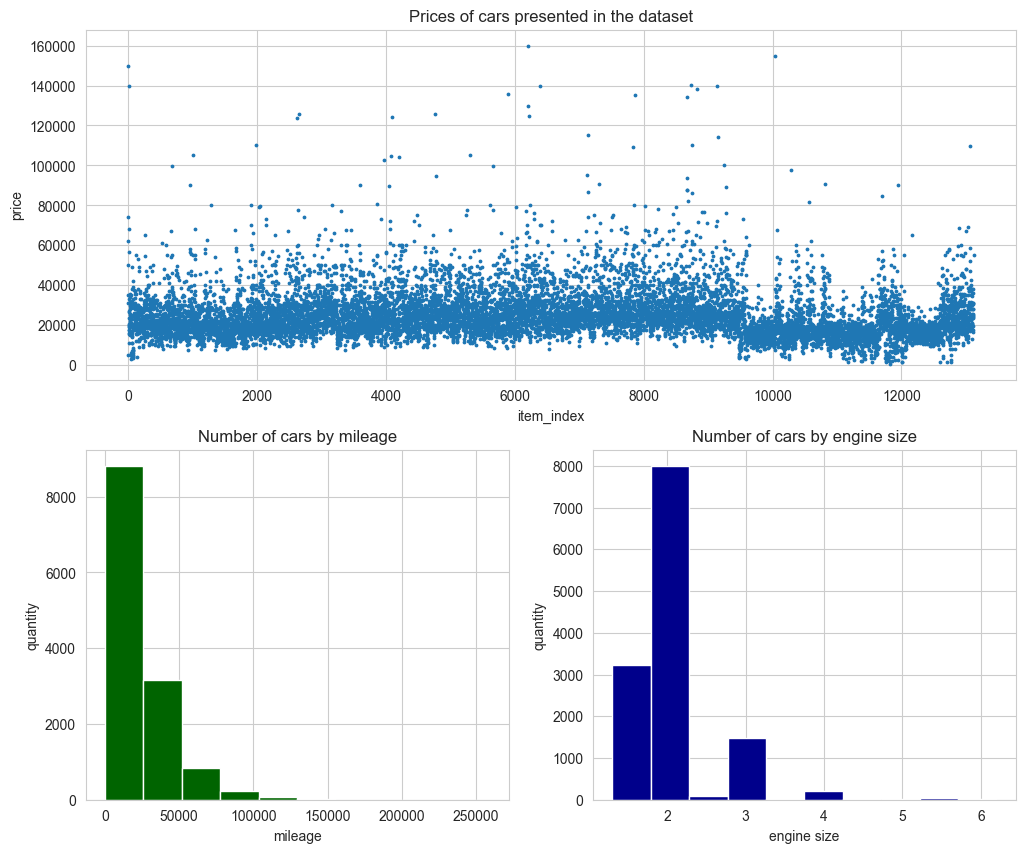

In [182]:
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12,10)
plt.subplot(2, 2, (1, 2))
plt.title("Prices of cars presented in the dataset")
plt.xlabel("item_index")
plt.ylabel("price")
plt.scatter(data.index, data['price'], s=3)
plt.subplot(223)
plt.hist(data['mileage'], color='Darkgreen')
plt.title("Number of cars by mileage")
plt.xlabel("mileage")
plt.ylabel("quantity")
plt.subplot(224)
plt.hist(data['engineSize'], color='Darkblue')
plt.title("Number of cars by engine size")
plt.xlabel("engine size")
plt.ylabel("quantity")
plt.show()

As I can see, people tend to sell Mercedeses of mileage from 0 to 25000 and of engine size 2.0 considerably more often then others. Cars with engines of medium power are more than twice more popular on Mercedes resale market than compact ones. Hence, I can assume people choose other brands for more economic cars.

Also what stands out is that the majority asks from 10000 to 40000 euros for their car, that is most of the cars lie in price range between 10 and 40 thousand euros. It can be considered average price range.

As for the 'year', I would like to look at relative quantity of cars on sale:

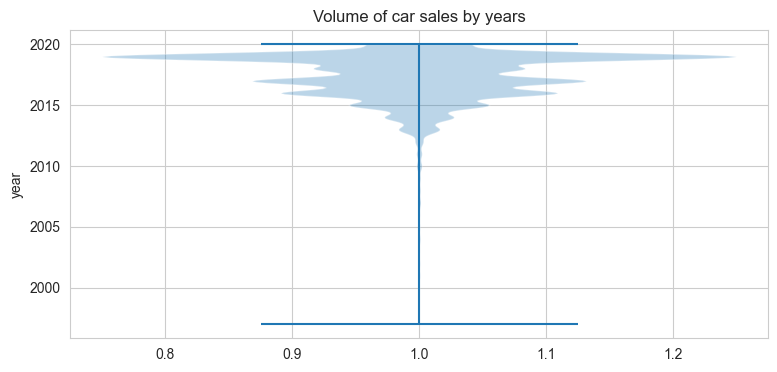

In [183]:
plt.rcParams["figure.figsize"] = (9,4)
plt.ylabel("year")
plt.title("Volume of car sales by years")
plt.violinplot(data['year'], points=300)
plt.show()

It can be seen that people sell cars of 2019 year of registration mostly. There are several reasons for this. If we assume 2020 is the year of the data collection, then the following reasons ought to take place:

- Some people regularly update their auto. 2020 was the year of restyling, so a lot of people sold their "old" cars in order to buy the newest model. It is a common phenomenon among Mercedes-Benz clients. So, the wave of sales fell on the previous year, namely 2019.

- People buy a car, drive it for a short period of time (a year or less), disapprove of it and sell.

- Difficult financial situation. People take a car loan, but then realize they cannot cope with it.

There are also quite high volumes for 2017 and 2016. Overall, the quantity decreases as the year goes down, and becomes insignificant at 2010: obviously, the younger the model, the higher demand it is in.

## Detailed Overview

It is time to look at specifics of our data in order to find any reasonable patterns.

At first I want to analyse the relationship between each pair of numeric variables of the dataset by identifying respective correlations and plotting the most catchy dependencies.

I will use scatter plots mostly, because they are more universal and help to informatively present almost all types of pairwise data.

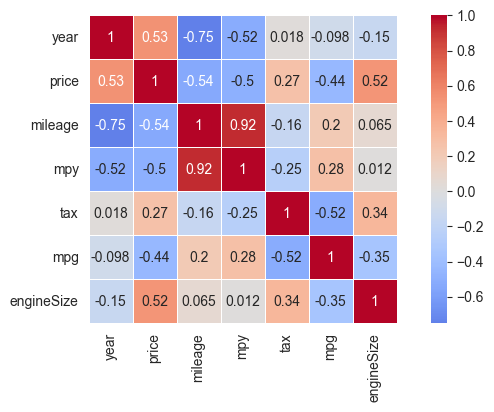

In [184]:
sns.heatmap(
    data.loc[:, ['year', 'price', 'mileage', 'mpy', 'tax', 'mpg', 'engineSize']].corr(),
    annot = True,
    linewidth=0.5,
    square=True,
    cmap='coolwarm',
    center=0
)
plt.show()

Consider positive correlations:

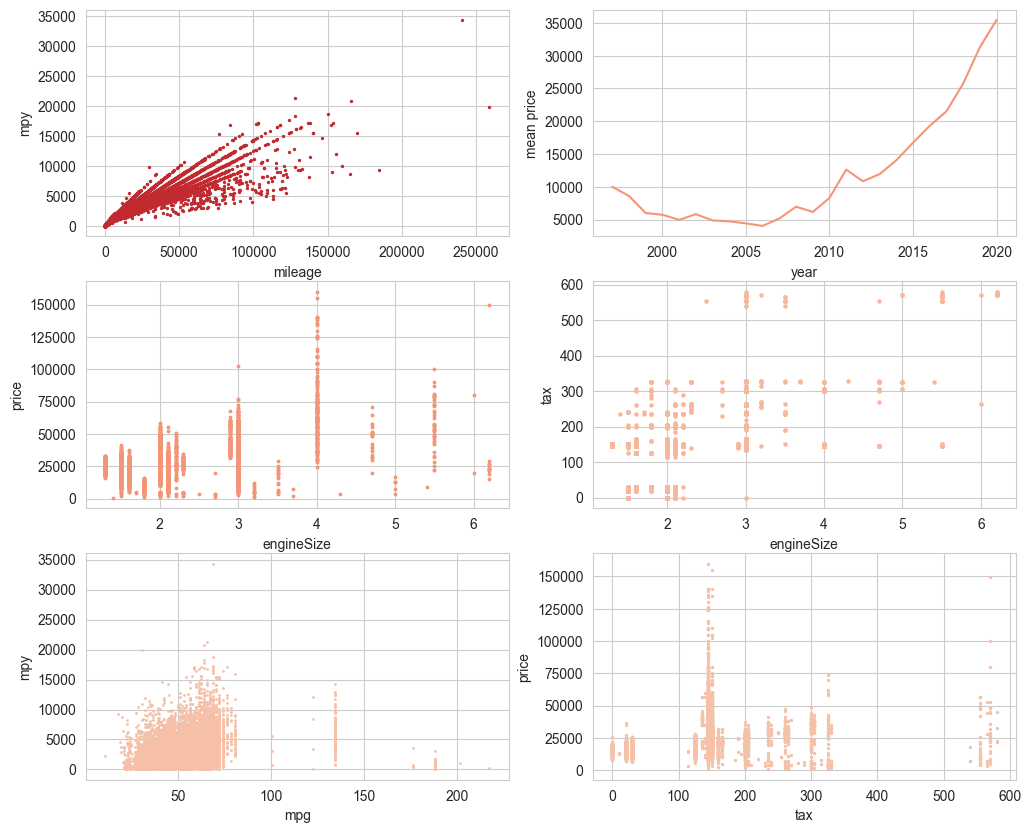

In [185]:
years = range(data['year'].min(), data['year'].max() + 1)
mean_prices = pd.Series(
    (data[data['year'] == x]['price'].mean() for x in years),
    index=years
)

plt.rcParams["figure.figsize"] = (12,10)
plt.subplot(321)
plt.xlabel("mileage")
plt.ylabel("mpy")
plt.scatter(data['mileage'], data['mpy'], s=2, c='#C12B30')
plt.subplot(322)
plt.xlabel("year")
plt.ylabel("mean price")
plt.plot(mean_prices, c='#F39577')
plt.subplot(323)
plt.xlabel("engineSize")
plt.ylabel("price")
plt.scatter(data['engineSize'], data['price'], s=3, c='#F39577')
plt.subplot(324)
plt.xlabel("engineSize")
plt.ylabel("tax")
plt.scatter(data['engineSize'], data['tax'], s=5, c='#F7B79B')
plt.subplot(325)
plt.xlabel("mpg")
plt.ylabel("mpy")
plt.scatter(data['mpg'], data['mpy'], s=1, c='#F5C0A7')
plt.subplot(326)
plt.xlabel("tax")
plt.ylabel("price")
plt.scatter(data['tax'], data['price'], s=2, c='#F5C1A9')
plt.show()

- **'mpy'** against **'mileage'** (correlation **0.92**):

    Such correlation may seem obvious. If a car is used on a daily basis (regularly, in other words), then the more it was driven in general, the more it was driven yearly. The fact that the age of a car increases over time keeps this growth almost linear.
- **'year'** against **'price'** (correlation **0.53**, mean price on graph):

    The latest models cost more than their "ancestors" (cars of the same model, released earlier). This is due to marketing reasons mostly, newer cars are most desired and are considered more trustworthy.
- **'engineSize'** against **'price'** (correlation **0.52**):

    High correlation, indicating that engine size directly influences the price. It may not be noticed straightaway, since the car's age also contributes a lot to the price, as I have just showed.
- **'engineSize'** against **'tax'** (correlation **0.34**):

    Medium correlation shows that in general people pay higher road taxes for more powerful cars.
-  **'mpy'** against **'mpg'** (correlation **0.28**):

    Medium correlation, which I interpret as economical cars are used by people more regularly and intensively, rather than powerful and fuel-consuming. This could also be clearly observed in the plot.
- **'tax'** against **'price'** (correlation **0.27**):
 
    Medium correlation, not distinctively seen in a plot, shows that higher road taxes are set for more expensive cars. This may seem logical if we recall that higher engine size, accounting for the considerable part of the price, leads to higher tax.

Consider negative correlations:

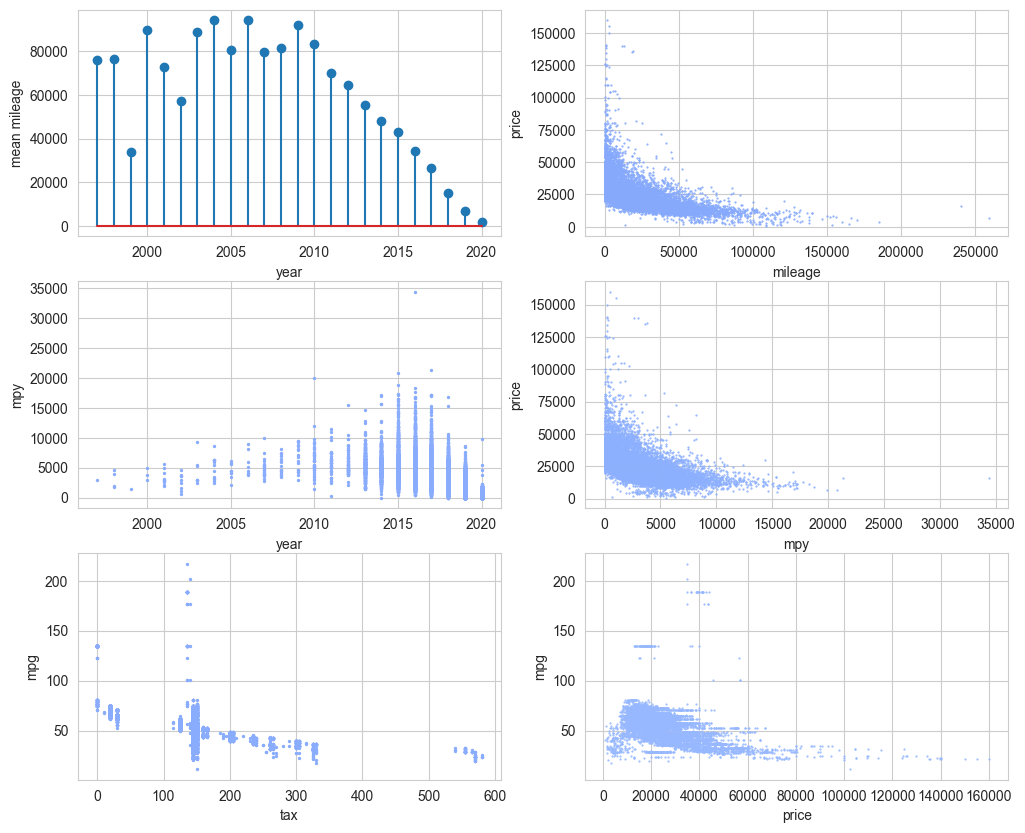

In [186]:
mean_mileages = pd.Series(
    (data[data['year'] == x]['mileage'].mean() for x in years)
)

plt.rcParams["figure.figsize"] = (12,10)
plt.subplot(321)
plt.xlabel("year")
plt.ylabel("mean mileage")
plt.stem(years, mean_mileages)
plt.subplot(322)
plt.xlabel("mileage")
plt.ylabel("price")
plt.scatter(data['mileage'], data['price'], s=0.3, c='#86A9FC')
plt.subplot(323)
plt.xlabel("year")
plt.ylabel("mpy")
plt.scatter(data['year'], data['mpy'], s=2, c='#89ACFD')
plt.subplot(324)
plt.xlabel("mpy")
plt.ylabel("price")
plt.scatter(data['mpy'], data['price'], s=0.3, c='#8DB0FE')
plt.subplot(325)
plt.xlabel("tax")
plt.ylabel("mpg")
plt.scatter(data['tax'], data['mpg'], s=2, c='#89ACFD')
plt.subplot(326)
plt.xlabel("price")
plt.ylabel("mpg")
plt.scatter(data['price'], data['mpg'], s=0.3, c='#97B8FF')
plt.show()

- **'year'** against **'mileage'** (correlation **-0.75**, mean mileage on graph):

    Strong negative correlation implies that newer cars are of less mileage, which is expected.
- **'price'** against **'mileage'** (correlation **-0.54**):

    It can be observed that the higher mileage a car has, the cheaper it is.
- **'mpy'** against **'year'** (correlation **-0.52**):

    High correlation. What stands out is that cars of years 2015-2017 have the widest ranges of 'mpy'. I suppose it can be explained in the following way: cars of these years were (by 2020) of a certain age to gain high mileage (unlike newer ones), but not too old to allow its age to decrease 'mpy' while it is driven rarely (which happens to older cars).
- **'price'** against **'mpy'** (correlation **-0.5**):

    The situation is quite similar to 'price' ag. 'mileage': the more intensively the car was used, the cheaper it is.
- **'mpg'** against **'tax'** (correlation **-0.52**):

    High correlation illustrates that higher fuel consumption results in higher tax.
- **'mpg'** against **'price'** (correlation **-0.44**):

    Medium negative correlation indicates that on average the lesser the 'mpy', the more the car costs. Low values of 'mpy' are associated with powerful expensive engines.

I also want to consider the dataset with respect to **'model'**.

I will start with determining the popularity of particular Mercedes models in the secondary market:

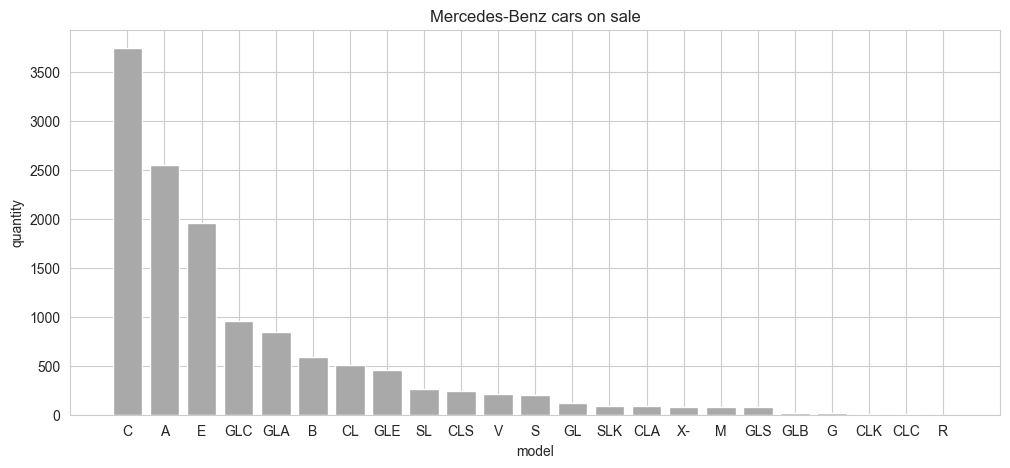

In [187]:
models_count = data['model'].value_counts(sort=True)
plt.rcParams["figure.figsize"] = (12,5)
plt.xlabel("model")
plt.ylabel("quantity")
plt.title("Mercedes-Benz cars on sale")
plt.bar(models_count.index, models_count, color='Darkgray')
plt.show()

Exact values:

In [188]:
pd.DataFrame({
    'model': models_count.index,
    'quantity': models_count.values
},
index=range(models_count.shape[0])
)

,model,quantity
0,C,3742
1,A,2551
2,E,1952
3,GLC,960
4,GLA,845
5,B,591
6,CL,511
7,GLE,460
8,SL,259
9,CLS,237


Let me take 3 outstandingly popular models, namely C, A and E, and illustrate their price against the year of registration.

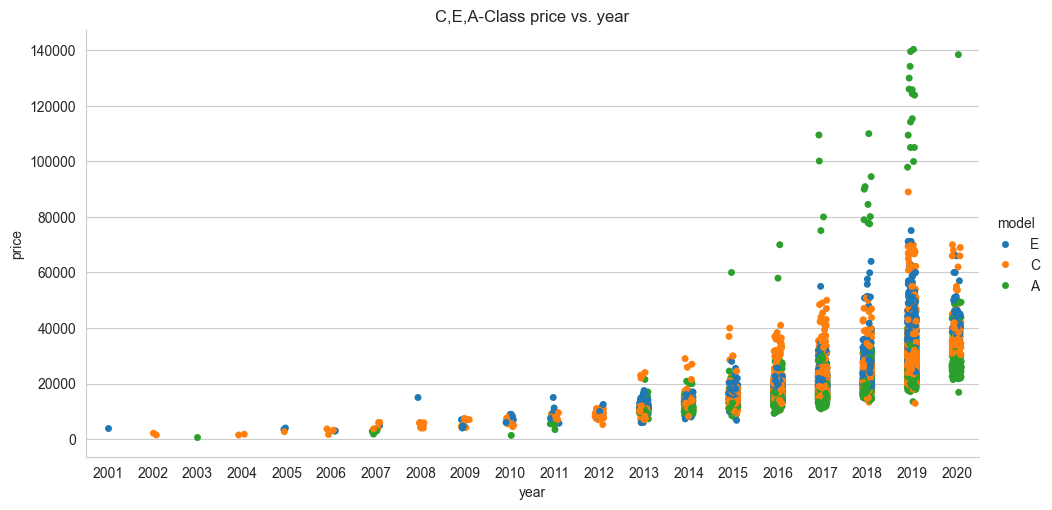

In [189]:
cea = data[(data['model'] == "C") | (data['model'] == "E") | (data['model'] == "A")]
cea = cea.loc[:, ['model', 'year', 'price']]

sns.catplot(data=cea, kind='strip', y='price', x='year', hue='model', aspect=2).set(
    title='C,E,A-Class price vs. year'
)
plt.show()

I can see that A-Class is generally cheaper than E and C, while E-Class and C-Class are in approximately the same price range each year. However, there is a strange "cloud" of expensive A-Classes, their prices are considerably above the bulk. I will observe the correspondent slice:

In [190]:
extreme_a = data[(data['model'] == "A") & (data['price'] > 55000)]
print(f"Shape: {extreme_a.shape[0]} rows, {extreme_a.shape[1]} columns")
extreme_a

Shape: 32 rows, 10 columns


,model,year,price,transmission,mileage,mpy,fuelType,tax,mpg,engineSize
686,A,2019,99950,Automatic,2013,504,Petrol,145,22.6,4.0
1011,A,2019,104999,Semi-Auto,5822,1456,Petrol,150,22.6,4.0
1285,A,2017,79999,Semi-Auto,13781,2297,Petrol,145,30.1,4.0
2034,A,2018,78995,Semi-Auto,8420,1684,Petrol,145,30.1,4.0
2629,A,2019,123846,Semi-Auto,2951,738,Petrol,145,22.1,4.0
2647,A,2019,125796,Automatic,637,160,Petrol,145,24.8,4.0
4094,A,2019,124366,Semi-Auto,880,220,Petrol,145,24.8,4.0
4759,A,2019,126000,Automatic,250,63,Petrol,145,24.6,4.0
4779,A,2018,94522,Automatic,1736,348,Petrol,145,24.8,4.0
5266,A,2018,77500,Semi-Auto,3600,720,Petrol,145,30.1,4.0


Judging by 'mpg', 'engineSize' and 'fuelType' these are classy powerful AMG models. Thus, the price is comparably high.

I will continue by identifying **how much do each model cost on average**, also taking mean engine size into account. I will take into consideration only latest models (2019 and 2020), because of age gaps and the fact that over time borders between models are being erased due to mileage.

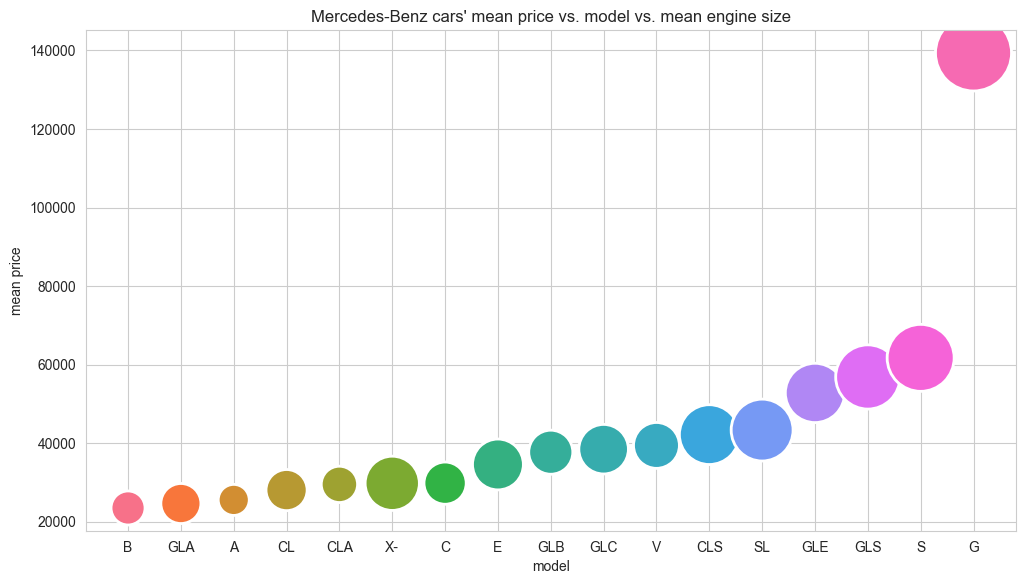

In [195]:
n = data[data['year'] > 2018].loc[:, ['model', 'price', 'engineSize']]
models = data['model'].unique()
all_mean_prices = pd.DataFrame({
    "model": models,
    "mean price": pd.Series(n[n['model'] == x]['price'].mean() for x in models),
    "engineSize": pd.Series(n[n['model'] == x]['engineSize'].mean() for x in models),
}).dropna()
all_mean_prices['mean price'] = all_mean_prices['mean price'].apply(math.ceil)
all_mean_prices = all_mean_prices.sort_values('mean price')

plt.rcParams["figure.figsize"] = (12,6.5)
sns.scatterplot(
    all_mean_prices, x='model', y='mean price', size='engineSize',
    hue='model',
    sizes=(500, 3000),
    legend=False).set(title='Mercedes-Benz cars\' mean price vs. model vs. mean engine size')
plt.show()

'model'-'price' and 'model'-'engineSize' relations are distinct. Previously recognized 'engineSize'-'price' correlation is proved. It is worth mentioning that engine size becomes extremely significant contributor to the price in the slice of 2019-2020 years:

In [192]:
print("2019-2020 engineSize'-'price' correlation:")
data[data['year'] > 2018].loc[:, ['price', 'engineSize']].corr()

2019-2020 engineSize'-'price' correlation:


,price,engineSize
price,1.000000,0.780318
engineSize,0.780318,1.000000


Final piece of analysis I want to conduct is dependence between 'fuelType' and 'mpg':

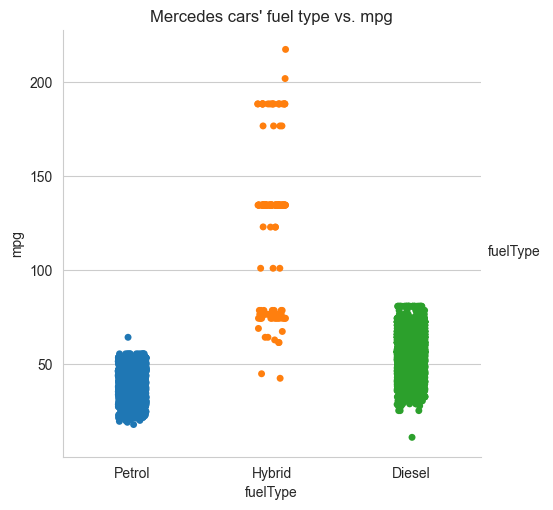

In [193]:
fuelmpg = data.loc[:, ['fuelType', 'mpg']]
sns.catplot(data=fuelmpg, kind='strip', x='fuelType', y='mpg', hue='fuelType').set(
    title='Mercedes cars\' fuel type vs. mpg'
)
plt.show()

Hybrid models on average can go far more on one galoon of fuel, because it is not their only source of power. In turn, diesel is meanly **38.76%** more economical than petrol.

## Hypothesis Checking

My hypothesis is rather simple and is as follows.

As I have previously discovered, G models have an outstandingly high mean price comparing to others, but what I also know is that price negatively correlates with 'mpg', which in turn is more or less associated with Petrol fuel type as I have just shown.

Hence, I claim that most of G-Class cars presented in the dataset work on petrol, rather then diesel or electricity. Moreover, such considerable gap in price regarding other models might indicate these Gs are powerful ones, which implies they have big engine sizes.

So, let me validate my assumptions:

In [197]:
g = data[data['model'] == 'G']
print(f"Shape: {g.shape[0]} rows, {g.shape[1]} columns")
g

Shape: 15 rows, 10 columns


,model,year,price,transmission,mileage,mpy,fuelType,tax,mpg,engineSize
3,G,2016,61948,Automatic,16000,2286,Petrol,325,30.4,4.0
4,G,2016,73948,Automatic,4000,572,Petrol,325,30.1,4.0
8,G,2019,139948,Automatic,12000,3000,Petrol,145,21.4,4.0
160,G,2015,52995,Semi-Auto,34400,4300,Diesel,570,25.2,3.0
3978,G,2019,102502,Semi-Auto,8691,2173,Diesel,150,11.0,3.0
5662,G,2015,99850,Semi-Auto,10000,1250,Petrol,570,20.5,5.5
5902,G,2018,135771,Semi-Auto,19000,3800,Petrol,145,21.4,4.0
6199,G,2020,159999,Semi-Auto,1350,450,Petrol,145,21.4,4.0
6386,G,2018,139995,Semi-Auto,13046,2610,Petrol,145,21.4,4.0
6576,G,2017,71995,Automatic,38247,6375,Petrol,145,20.5,5.5


Indeed, I can distinctively see my logical chain takes place and 67% of G models have petrol-powered engines. 33%, 53%, 13% of them are of size 3.0, 4.0 and 5.5 respectively, which are conventionally high values.